# Hierarchical forecasting I with `numpyro_forecast`

This notebook ports the blog post [**Hierarchical forecasting with NumPyro (part I)**](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. This example is by itself a port of the first part of the original Pyro example: [**Forecasting III: hierarchical models**](https://pyro.ai/examples/forecasting_iii.html). It generalizes the [univariate notebook](forecasting_univariate.html) from a single series to many: we forecast hourly **BART arrivals to one destination** (`EMBR`, Embarcadero) from all `50` origin stations at once. Each origin keeps its own random-walk level and weekly seasonality, but they share global hyperparameters and a single observation scale, which lets information pool across the series.

> **Note on reproducibility.** We match the blog's data, seed, optimizer and step counts. Results reproduce the blog's behavior and CRPS magnitude but are not bit-for-bit identical: the forecast horizon uses the package's separate-`_future`-site mechanism rather than re-running the guide over the full covariates.

## Prepare notebook

In [1]:
import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from jax import random
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    draw_posterior,
    eval_crps,
    forecast,
    innovations,
    predict,
    predict_in_sample,
)
from numpyro_forecast.datasets import load_bart_hierarchical
from numpyro_forecast.features import periodic_repeat
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We load the windowed origin-destination panel (`log1p` counts, `90` training days plus `2` test weeks) and select arrivals to `EMBR` from every origin. The `log1p` transform tames the multiplicative growth while staying defined at zero rides, which matters for hourly counts. The result is a `(time, n_series)` array where each of the `50` origins is one series, time is at axis `-2`, and the series dimension is at axis `-1`.

data shape: (2496, 50) | split: 2160


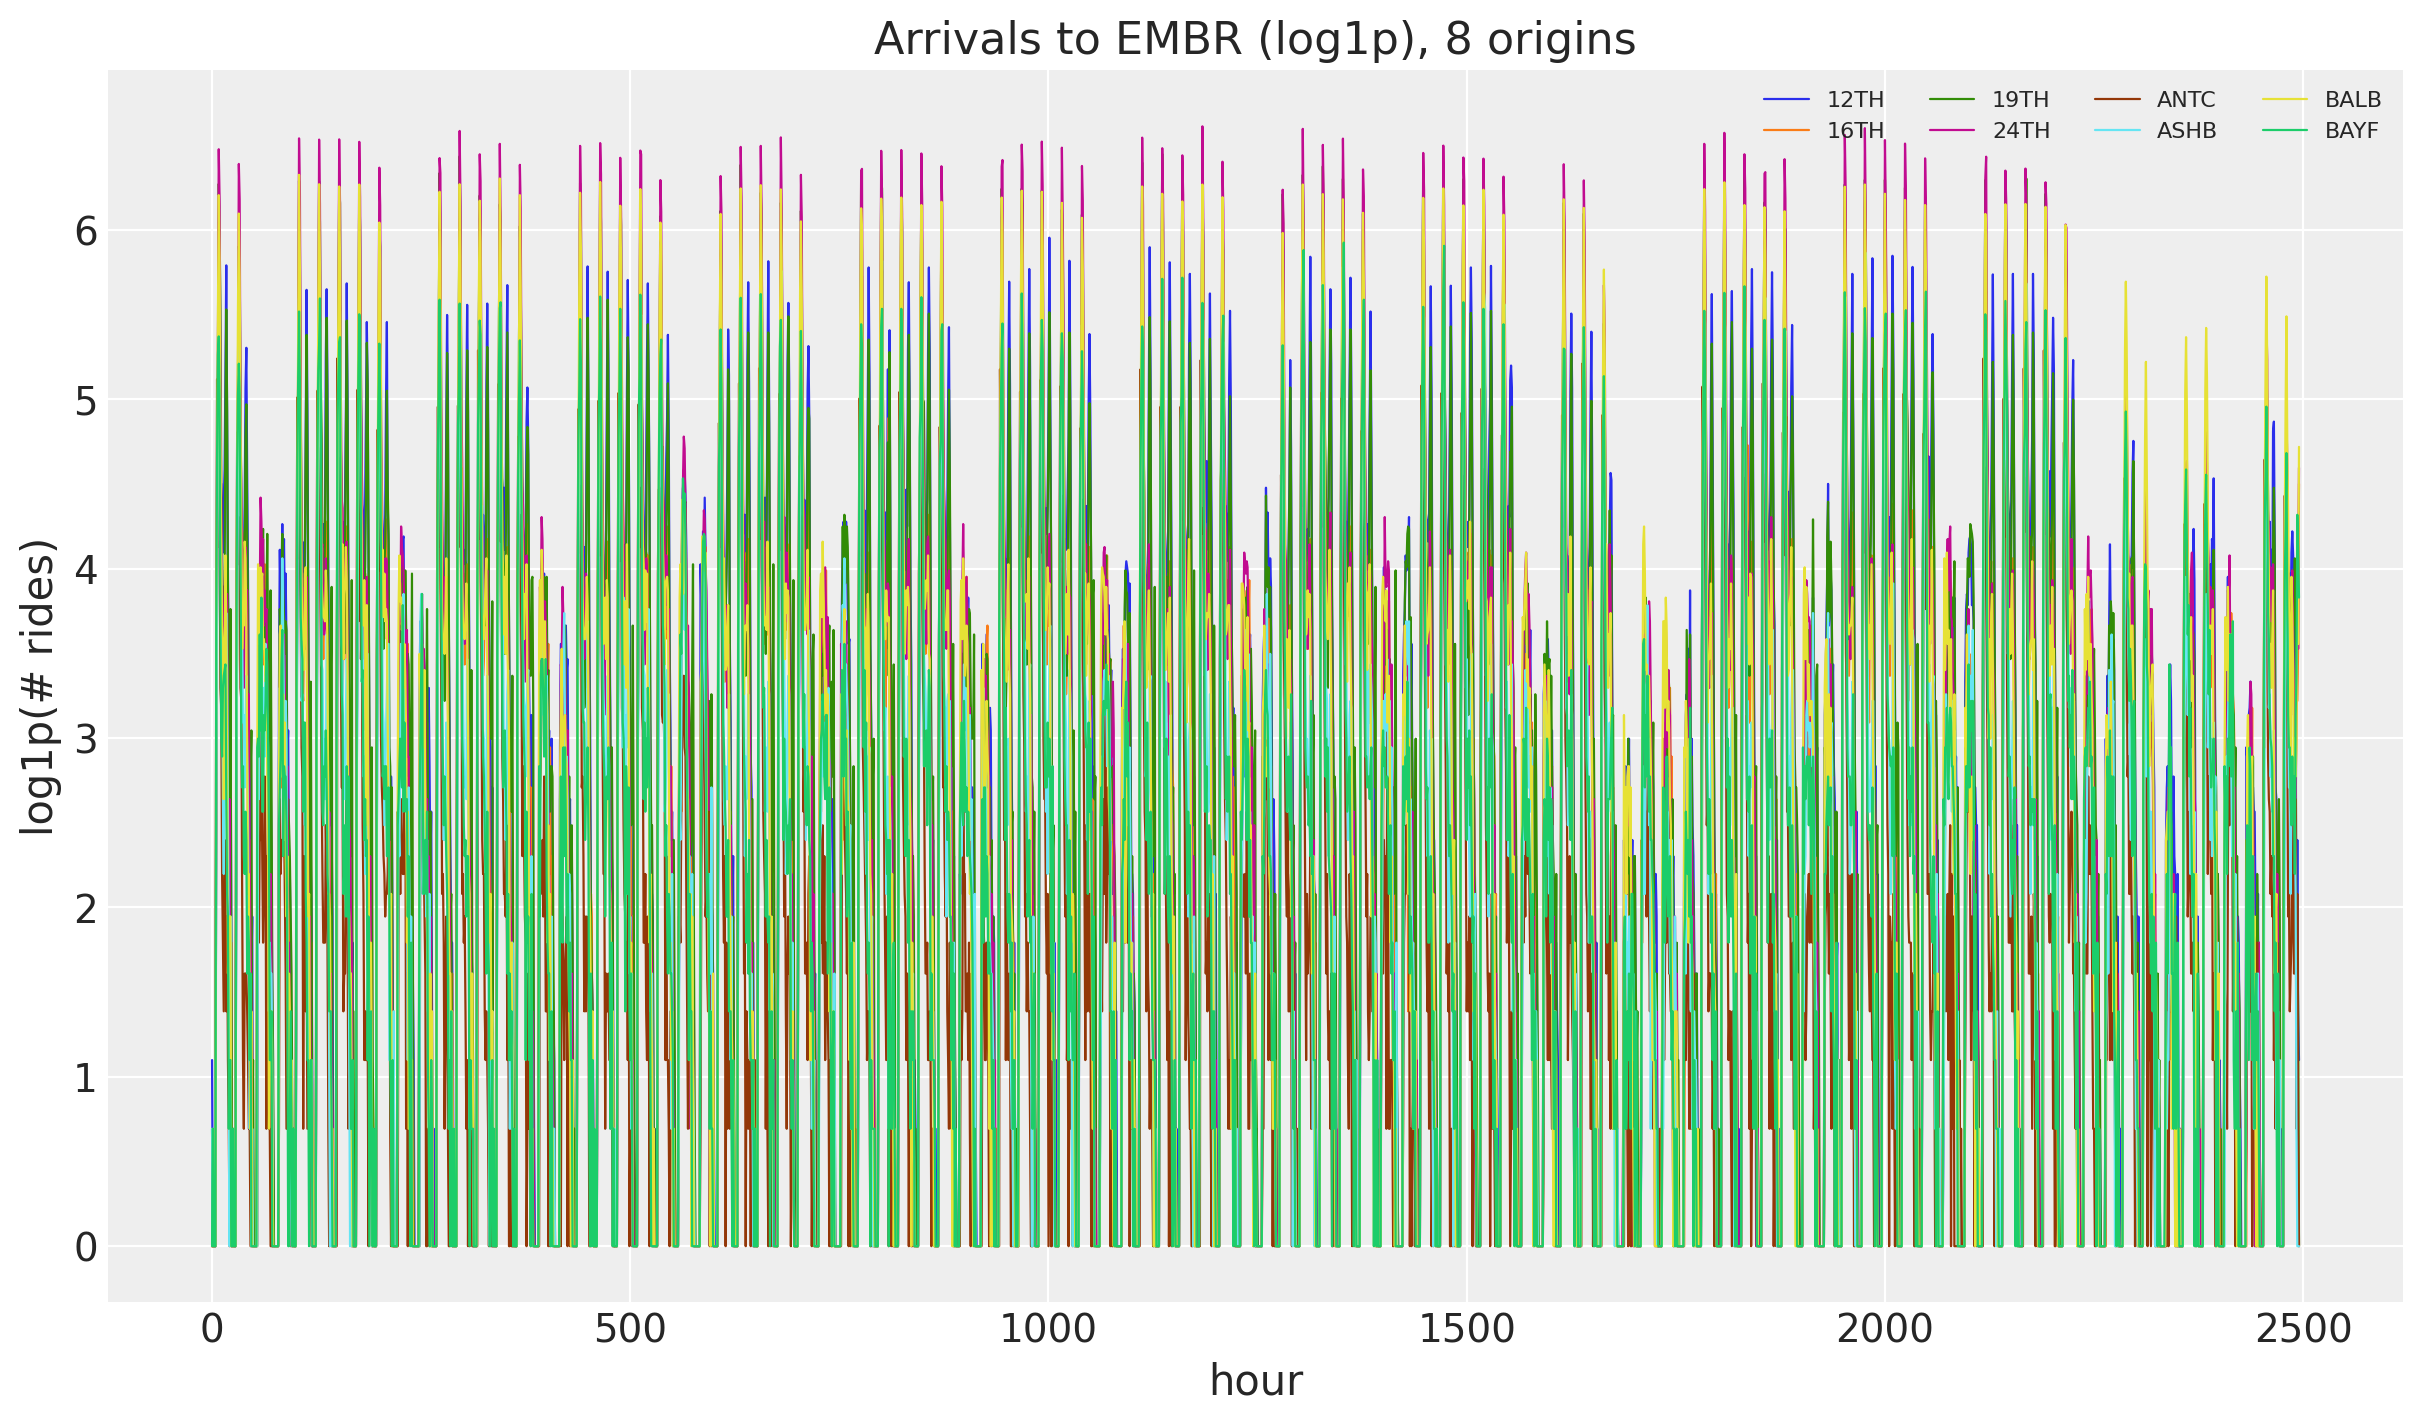

In [2]:
y_full, split, stations = load_bart_hierarchical()
embr = stations.index("EMBR")
data = jnp.swapaxes(y_full[:, :, embr], 0, 1)  # (time, n_series)
n_series = data.shape[-1]
print("data shape:", data.shape, "| split:", split)

fig, ax = plt.subplots()
for i in range(8):
    ax.plot(np.asarray(data[:, i]), lw=0.8, label=stations[i])
ax.legend(ncol=4, fontsize=8)
ax.set(title="Arrivals to EMBR (log1p), 8 origins", xlabel="hour", ylabel="log1p(# rides)");

## Train-test split

We hold out the last two weeks (`336` hours) for testing. The model learns seasonality internally from the time index, so the covariates here are just dummy zeros: only their shape (the duration) is read, to tell training from forecasting.

In [3]:
T0 = 0
T1 = split  # 2_160
T2 = data.shape[0]  # 2_496

y_train = data[T0:T1]
y_test = data[T1:T2]
covariates = jnp.zeros((T2, n_series))
covariates_train = covariates[T0:T1]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

# Christmas anomaly index (BART series starts 2011-01-01, hourly).
dates = pd.date_range("2011-01-01", periods=78_888, freq="h")[-T2:]
christmas = np.flatnonzero((dates.month == 12) & (dates.day == 25))
christmas_index = int(christmas[0]) if len(christmas) else None
print("christmas index:", christmas_index)

train: (2160, 50) test: (336, 50)
christmas index: 2328


## Model specification

This is the univariate model lifted to a panel. Each series $s$ gets its own random-walk level $\ell_{t,s}$ and its own weekly seasonal profile (one value per hour-of-week, `168` in total), and all series share the same global drift scale and observation scale $\sigma$:

\begin{align*}
\mu_{t,s} & = \ell_{t,s} + \text{seasonal}_{(t \bmod \text{period}),\,s} \\
\ell_{t,s} & = \ell_{t-1,s} + \delta_{t,s} \\
\delta_{t,s} & \sim \text{Normal}(0, \sigma_\text{drift}) \\
y_{t,s} & \sim \text{Normal}(\mu_{t,s}, \sigma).
\end{align*}

The hierarchy is expressed with `numpyro.plate`. We call the `innovations` building block inside an `n_series` plate (it opens its own `time` plate at axis `-2`), so the drift and its forecast companion `drift_future` are sampled per series. The weekly seasonal lives under the `n_series` and `hour_of_week` plates, so it is estimated once per hour-of-week per series, then tiled across the full horizon with `periodic_repeat`. Sharing the global hyperparameters across the plate is what couples the series together. The model is a plain NumPyro model function `(covariates, data=None)`; because the seasonal period is a modeling choice, a small factory closes over it and returns the function.

In [4]:
def make_multi_series_model(period: int = 24 * 7) -> ForecastModel:
    """Build the per-series local level + weekly seasonality model with a shared Normal scale."""

    def multi_series_model(covariates: Array, data: Array | None = None) -> None:
        """Define the multi-series forecasting model."""
        h = Horizon.from_data(covariates, data)
        n_series = covariates.shape[-1]
        duration = covariates.shape[-2]

        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
        centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

        with numpyro.plate("n_series", n_series, dim=-1):
            drift = innovations(
                h,
                "drift",
                lambda: dist.Normal(0.0, drift_scale),
                reparam=LocScaleReparam(centered=centered),
            )
            with numpyro.plate("hour_of_week", period, dim=-2):
                # asarray narrows numpyro's union return type for the type checker.
                seasonal = jnp.asarray(numpyro.sample("seasonal", dist.Normal(0.0, 5.0)))

        level = jnp.cumsum(drift, axis=-2)
        prediction = level + periodic_repeat(seasonal, duration, axis=-2)

        predict(h, dist.Normal(0.0, sigma), prediction)

    return multi_series_model

Let's visualize the model:

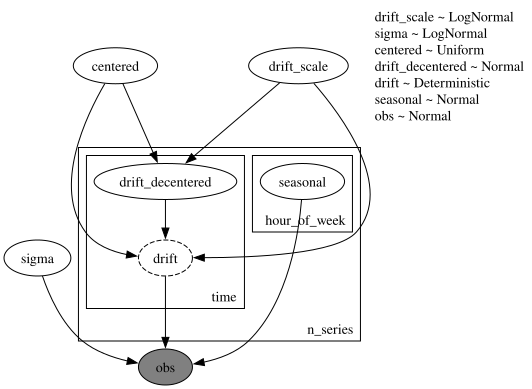

In [5]:
period = 24 * 7  # weekly seasonality (hours)
model = make_multi_series_model(period=period)

numpyro.render_model(
    model,
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

As usual (highly recommended!), we run prior predictive checks before fitting. We draw from the prior over the training window and overlay the $50\%$ and $94\%$ HDI bands on the last three weeks of training data for eight origins. The ranges look reasonable: wide enough to admit the data without being absurd.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_7688/757652965.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


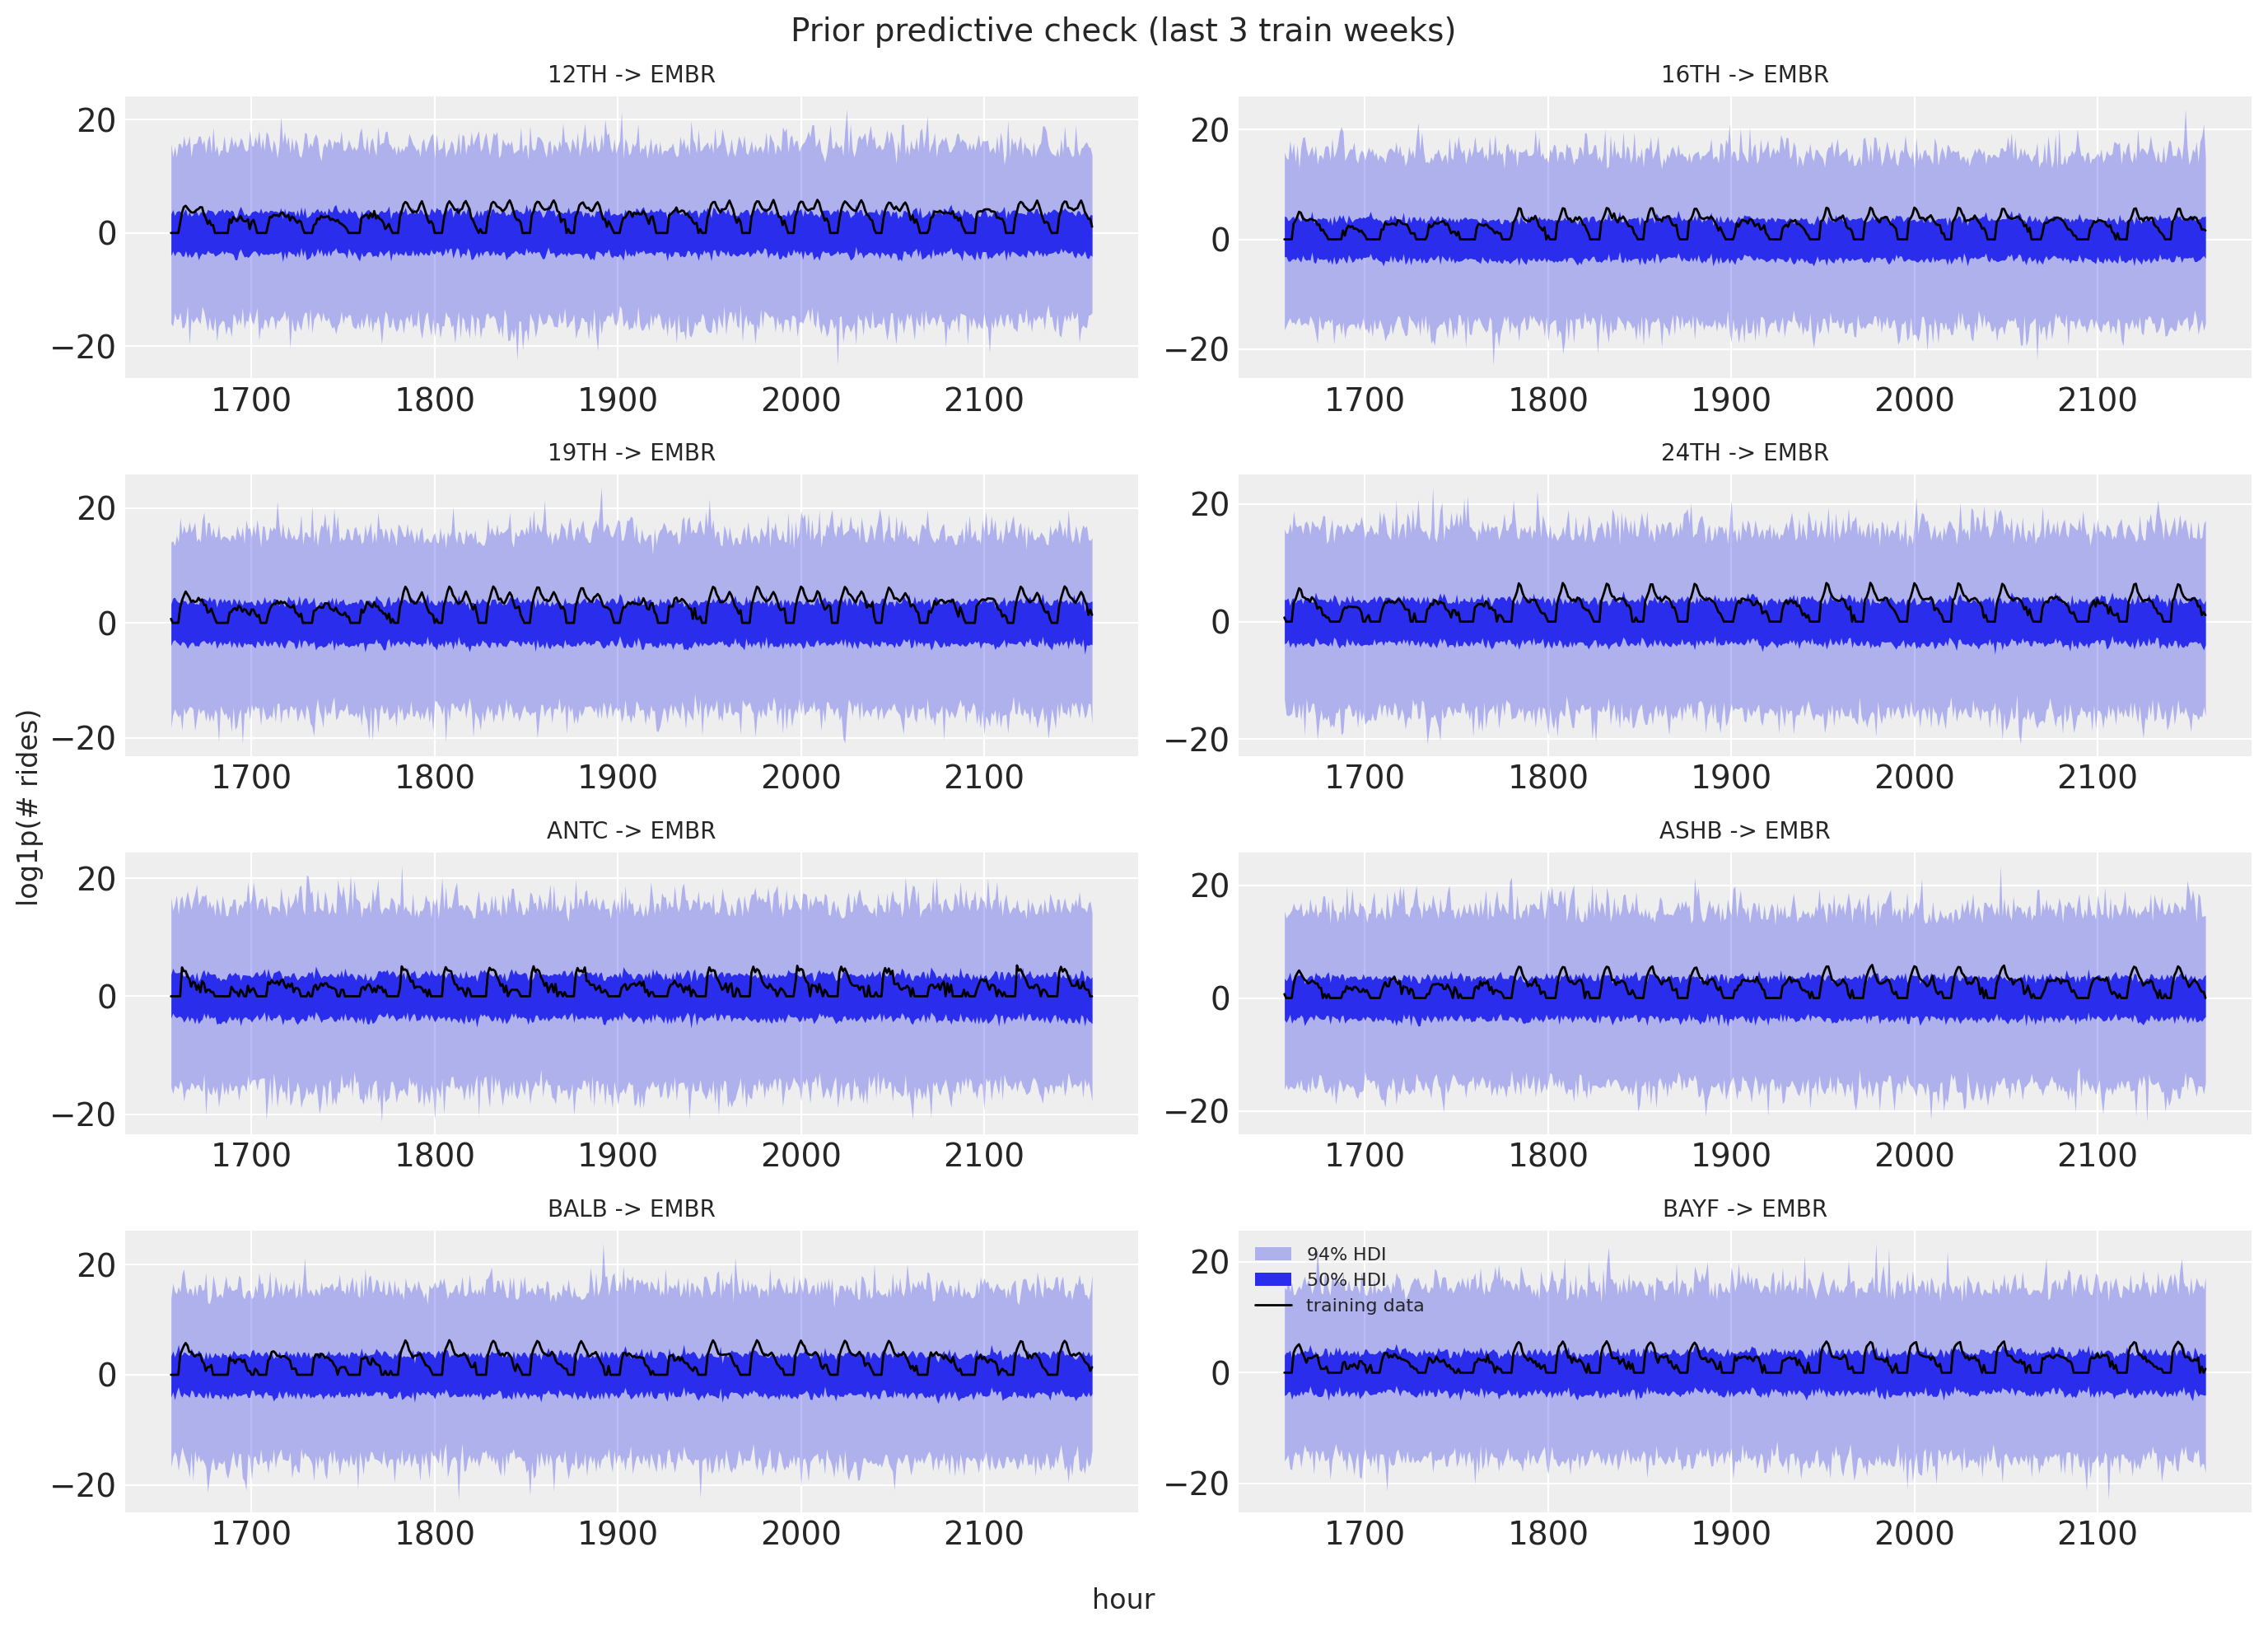

In [6]:
n_plot = 8  # origins shown in the facet grid
dest = "EMBR"
series = list(range(n_plot))


def faceted_idata(
    obs: Array | np.ndarray, t: Array | np.ndarray, group: str = "posterior_predictive"
) -> xr.DataTree:
    """Pack ``(draws, time, series)`` predictions into a DataTree for `plot_lm` faceting.

    The independent variable in ``constant_data`` carries the ``series`` dimension so that
    `plot_lm` facets one panel per series (`plot_dim="time"`).
    """
    t = np.asarray(t, dtype=float)
    x_grid = np.broadcast_to(t[:, None], (len(t), n_plot))
    return az.from_dict(
        {
            group: {"obs": np.asarray(obs)[None]},
            "observed_data": {"obs": np.zeros((len(t), n_plot))},
            "constant_data": {"t": x_grid},
        },
        coords={"time": t, "series": series},
        dims={"obs": ["time", "series"], "t": ["time", "series"]},
    )


prior_predictive = Predictive(model, num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"]

lo = T1 - 3 * period  # last three weeks of train
t_train = time_train[lo:T1].astype(float)

pc = az.plot_lm(
    faceted_idata(prior_obs[:, lo:T1, :n_plot], t_train, group="prior_predictive"),
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    col_wrap=2,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (14, 10)},
)
# Observed series on every facet in one call (subset per series by `pc.map`).
truth_da = xr.DataArray(
    np.asarray(y_train[lo:T1, :n_plot]),
    dims=["time", "series"],
    coords={"time": t_train, "series": series},
    name="t",
)
x_da = xr.DataArray(t_train, dims=["time"], coords={"time": t_train})
pc.map(
    az.visuals.line_xy, "truth", data=truth_da, x=x_da, ignore_aes=pc.aes_set, color="black", lw=1
)
for i in series:
    pc.get_target("t", {"series": i}).set_title(f"{stations[i]} -> {dest}", fontsize=10)
ax0 = pc.get_target("t", {"series": n_plot - 1})
bands = pc.viz["ci_band"]["t"].sel(series=n_plot - 1)
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
train_line = pc.viz["truth"]["t"].sel(series=n_plot - 1).item()
train_line.set_label("training data")
ax0.legend(handles=[band_94, band_50, train_line], loc="upper left", fontsize=8)
fig = pc.viz["figure"].item()
fig.supxlabel("hour")
fig.supylabel("log1p(# rides)")
fig.suptitle("Prior predictive check (last 3 train weeks)", fontsize=14)
fig.tight_layout();

## Inference with SVI

We fit the model with plain NumPyro SVI: an `AutoNormal` guide, `Adam`, and `SVI.run`. Plotting the ELBO on a log scale makes the convergence easy to read.

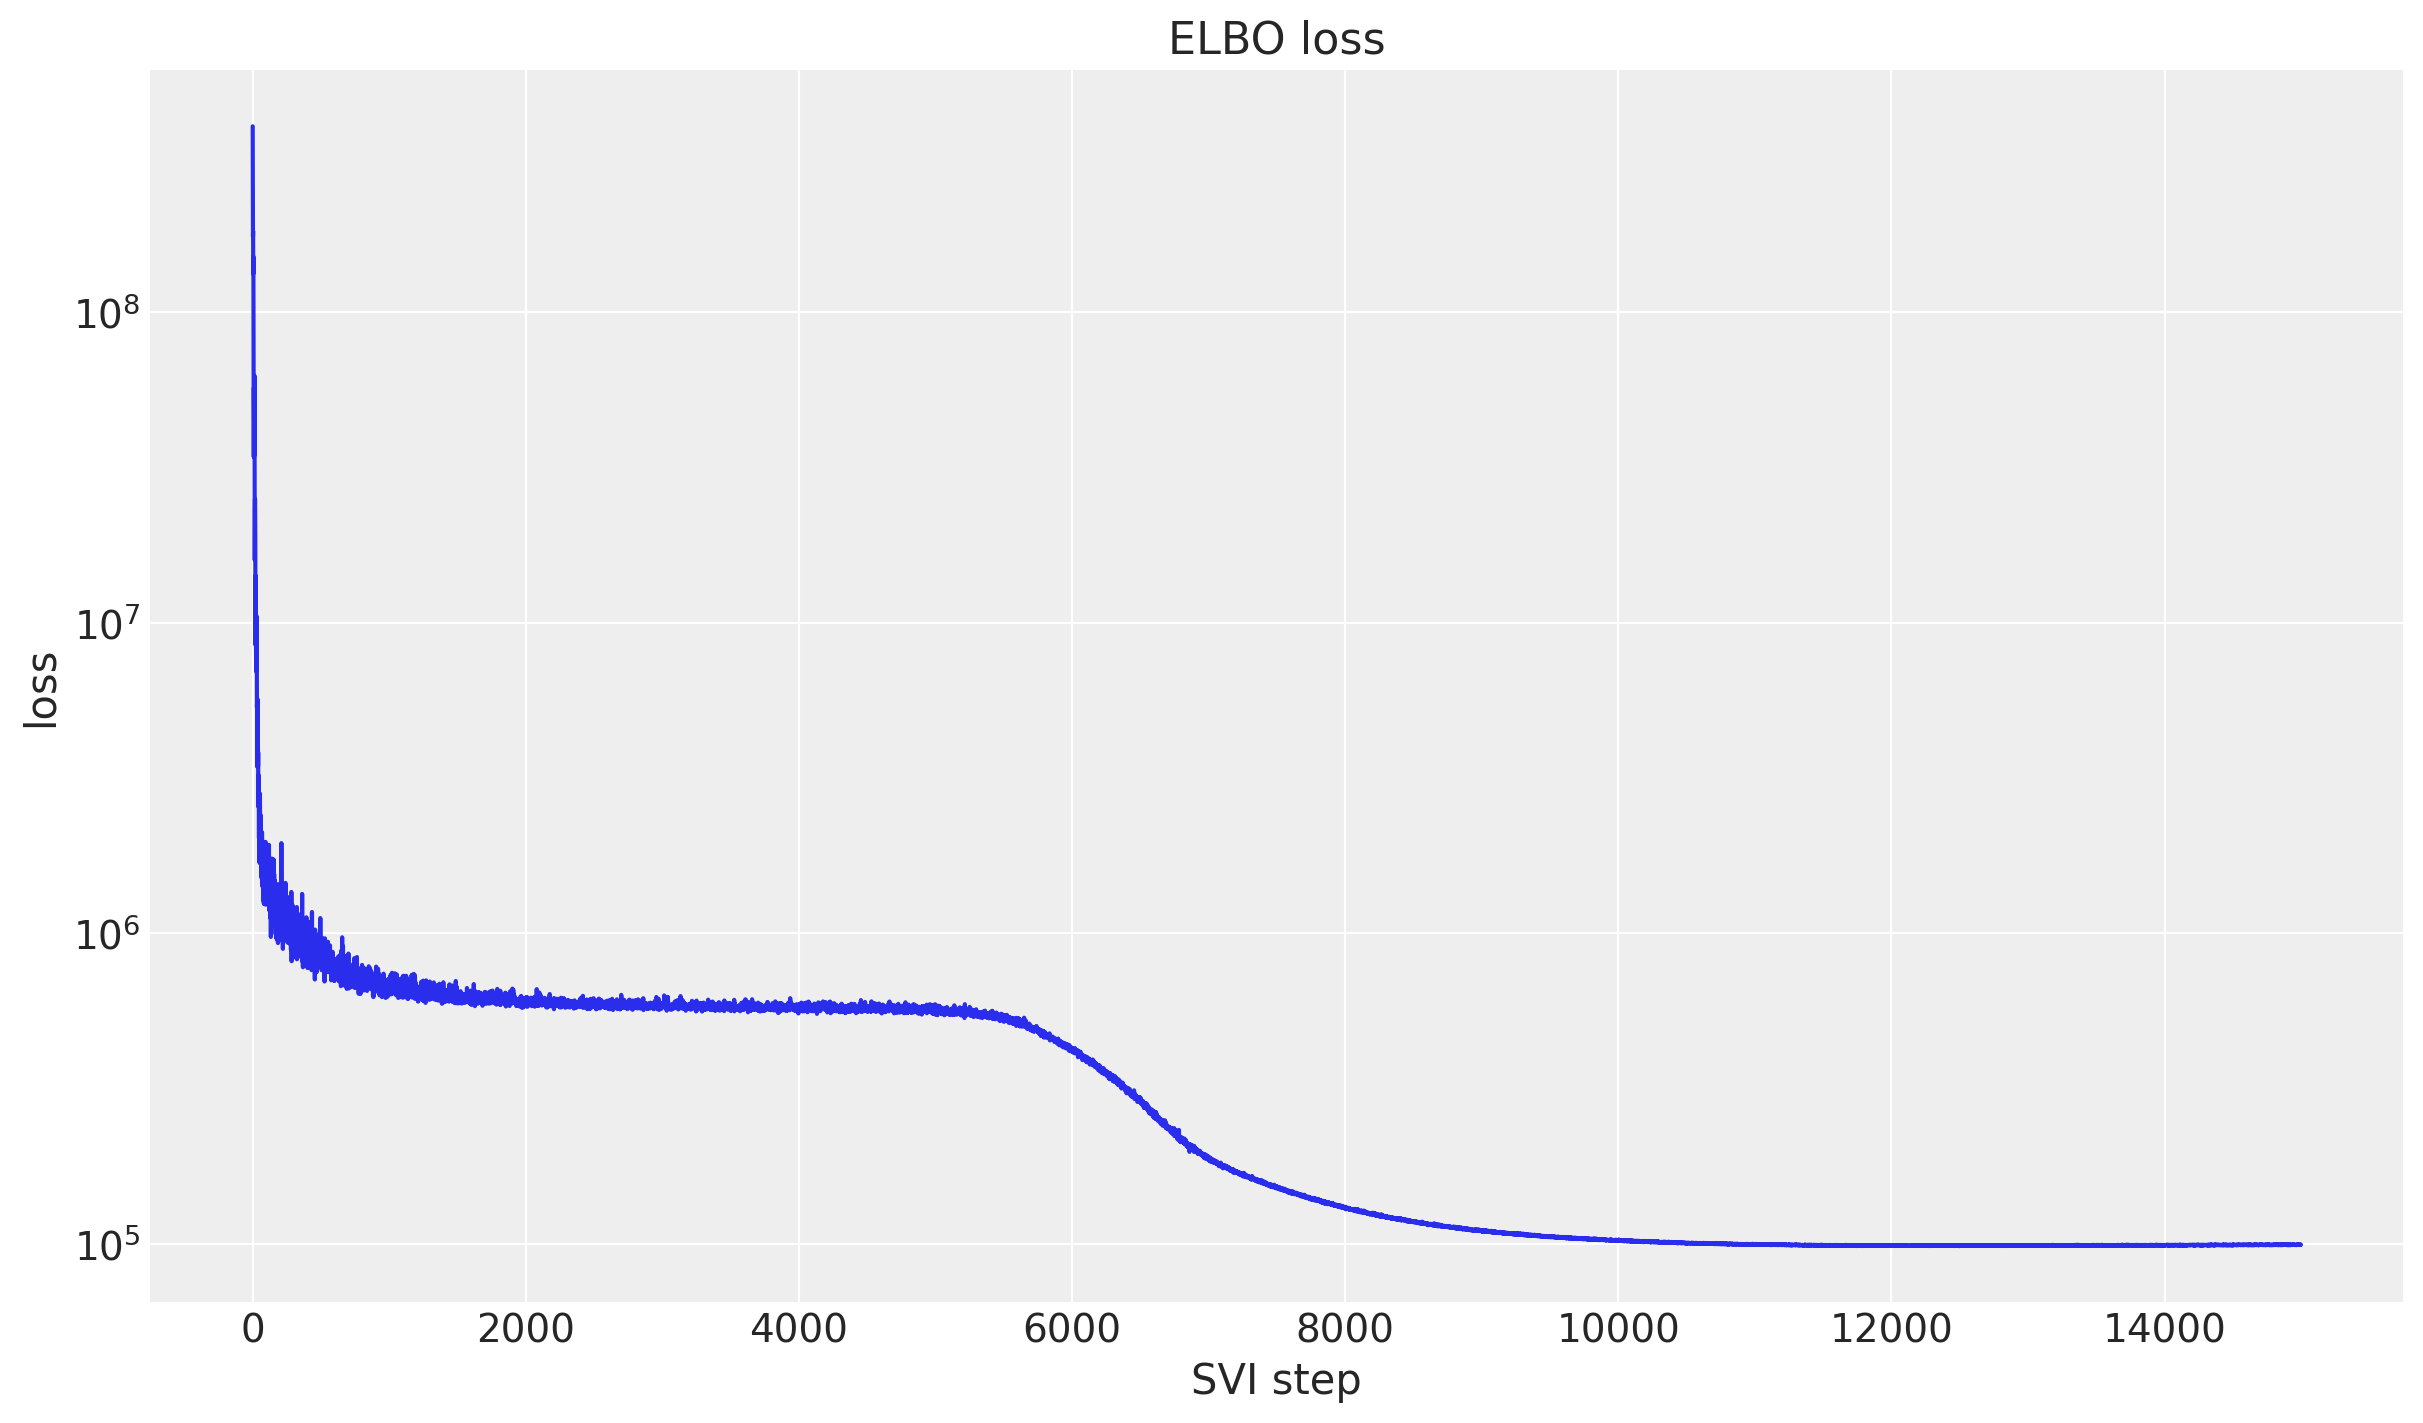

In [7]:
rng_key, rng_subkey = random.split(rng_key)
guide = AutoNormal(model)
svi = SVI(model, guide, Adam(step_size=0.05), Trace_ELBO())
svi_result = svi.run(rng_subkey, 15_000, covariates_train, y_train, progress_bar=False)

fig, ax = plt.subplots()
ax.plot(svi_result.losses)
ax.set_yscale("log")
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

We draw `1_500` posterior samples from the fitted guide with `draw_posterior`, push them through the model over the train window with `predict_in_sample` and over the test horizon with `forecast`, then score both with CRPS. Since the data live on the `log1p` scale, which is non-negative, we clip the predictions at zero before scoring.

In [8]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)

posterior = draw_posterior(key_post, guide, svi_result.params, 1_500)
train_pp = predict_in_sample(key_pp, model, posterior, covariates_train)
forecast_draws = forecast(key_fc, model, posterior, y_train, covariates)

train_pp = jnp.clip(train_pp, min=0.0)
forecast_draws = jnp.clip(forecast_draws, min=0.0)

crps_train = eval_crps(train_pp, y_train)
crps_test = eval_crps(forecast_draws, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")

Train CRPS: 0.2077


Test CRPS:  0.3675


## Forecast visualization

Eight origins arriving at `EMBR`: the in-sample posterior predictive (blue, last three train weeks) and the forecast (orange) with $50\%$ and $94\%$ HDI bands, the train/test split, and the observed series in black. The shaded band marks Christmas day.

The model does quite well on most of the test window, but it clearly struggles around Christmas: ridership collapses on the holiday and the forecast, which only knows about the weekly cycle, does not see it coming. This is the expected failure mode of a model without holiday information. The fixes are to feed it more history (so it has seen past Christmases) or to add explicit holiday features, for example dummy variables or Gaussian bump functions around special dates.

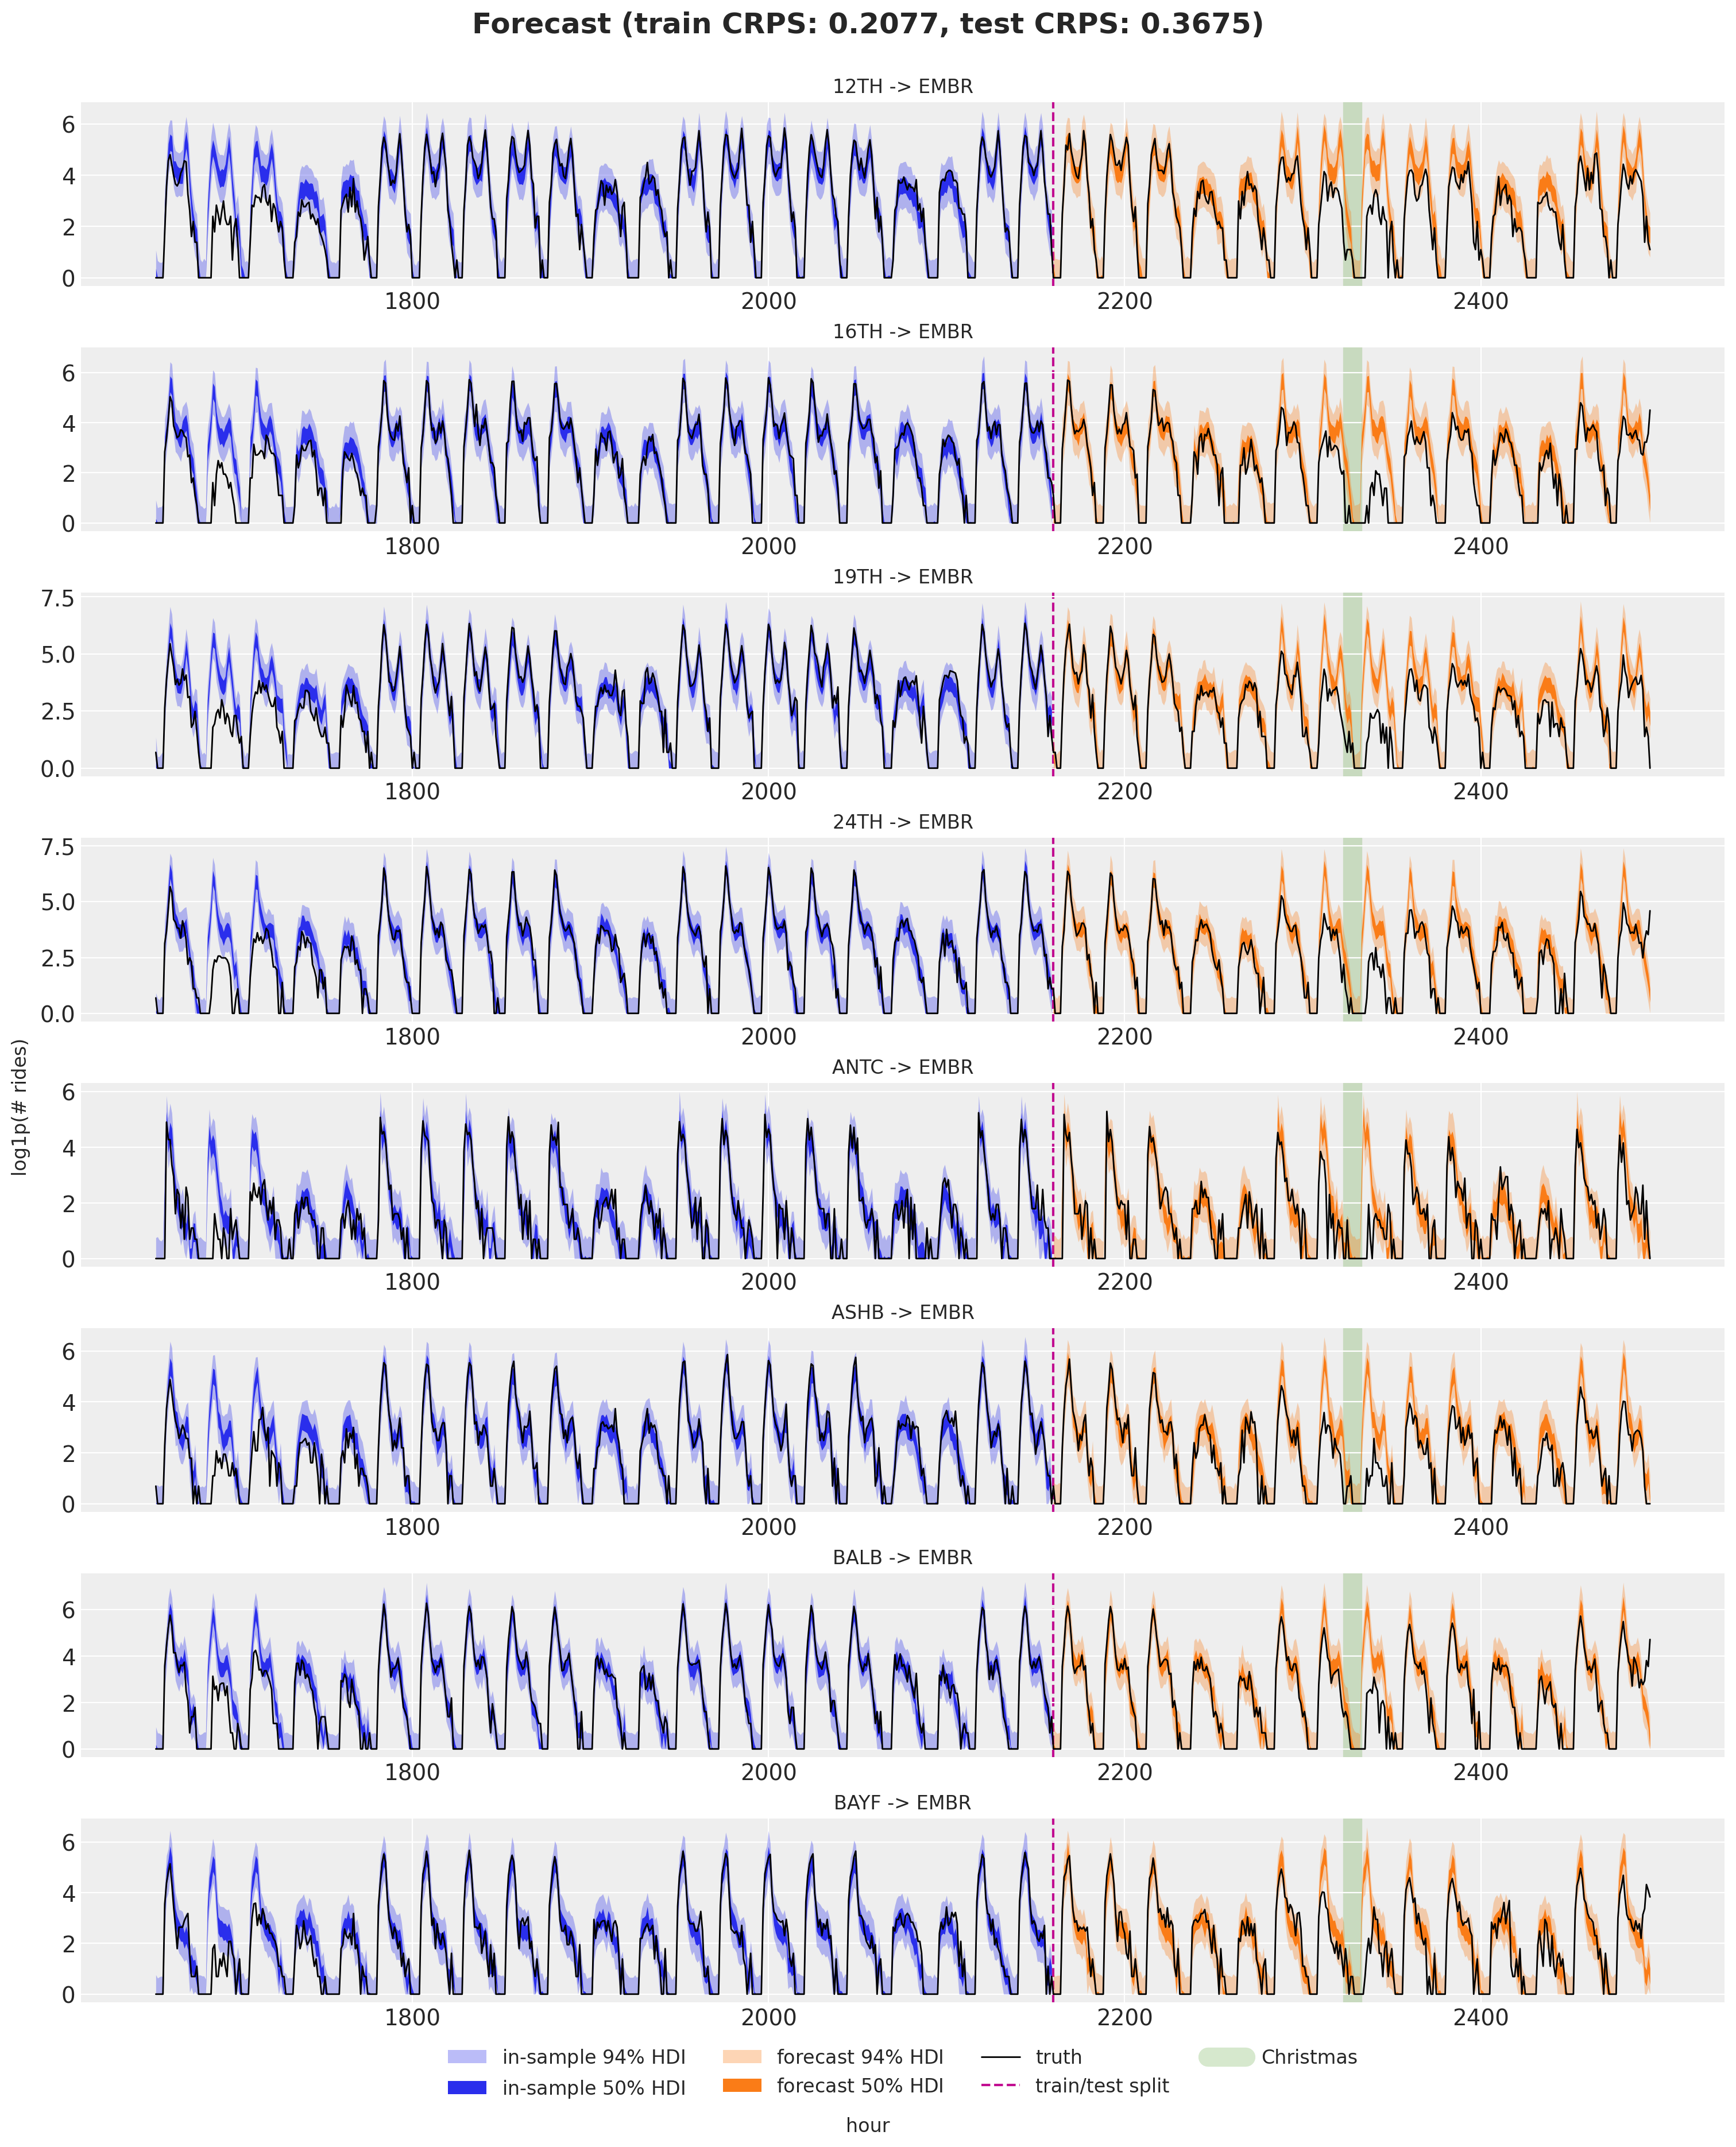

In [9]:
t_test = time_test.astype(float)
t_full = time[lo:T2].astype(float)

pc = az.plot_lm(
    faceted_idata(train_pp[:, lo:T1, :n_plot], t_train),
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    col_wrap=1,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    figure_kwargs={"figsize": (15, 18)},
)
train_bands = pc.viz["ci_band"]["t"].sel(series=n_plot - 1)
band_train_94 = train_bands.sel(prob=0.94).item()
band_train_50 = train_bands.sel(prob=0.5).item()
az.plot_lm(
    faceted_idata(forecast_draws[:, :, :n_plot], t_test),
    y="obs",
    x="t",
    plot_dim="time",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
)

# Observed series and the split / Christmas markers on every facet, each in one call.
truth_da = xr.DataArray(
    np.asarray(data[lo:T2, :n_plot]),
    dims=["time", "series"],
    coords={"time": t_full, "series": series},
    name="t",
)
x_da = xr.DataArray(t_full, dims=["time"], coords={"time": t_full})
pc.map(
    az.visuals.line_xy, "truth", data=truth_da, x=x_da, ignore_aes=pc.aes_set, color="black", lw=1
)
split_da = xr.DataArray(
    np.full(n_plot, float(T1)), dims=["series"], coords={"series": series}, name="t"
)
pc.map(az.visuals.vline, "split", data=split_da, ignore_aes=pc.aes_set, color="C3", ls="--")
if christmas_index is not None:
    xmas_da = xr.DataArray(
        np.full(n_plot, float(christmas_index)),
        dims=["series"],
        coords={"series": series},
        name="t",
    )
    pc.map(
        az.visuals.vline, "xmas", data=xmas_da, ignore_aes=pc.aes_set, color="C2", lw=12, alpha=0.2
    )

for i in series:
    pc.get_target("t", {"series": i}).set_title(f"{stations[i]} -> {dest}", fontsize=12)

# Build the legend once, on the first facet, from the real band and line artists.
ax0 = pc.get_target("t", {"series": n_plot - 1})
test_bands = pc.viz["ci_band"]["t"].sel(series=n_plot - 1)
band_test_94 = test_bands.sel(prob=0.94).item()
band_test_50 = test_bands.sel(prob=0.5).item()
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
truth_line = pc.viz["truth"]["t"].sel(series=n_plot - 1).item()
split_line = pc.viz["split"]["t"].sel(series=n_plot - 1).item()
truth_line.set_label("truth")
split_line.set_label("train/test split")
handles = [band_train_94, band_train_50, band_test_94, band_test_50, truth_line, split_line]
if christmas_index is not None:
    xmas_line = pc.viz["xmas"]["t"].sel(series=n_plot - 1).item()
    xmas_line.set_label("Christmas")
    handles.append(xmas_line)

fig = pc.viz["figure"].item()
fig.supxlabel("hour")
fig.supylabel("log1p(# rides)")
ax0.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=4, fontsize=12)
fig.suptitle(
    f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## Next steps

Here we pooled `50` origins into a single destination. In [part II](hierarchical_forecasting_2.html) we model the full `50x50` origin-destination panel at once, adding a static pairwise station affinity and separate origin and destination noise scales.

## References

- Orduz, J. [*Hierarchical forecasting with NumPyro (part I)*](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/).
- Pyro. [*Forecasting III: Hierarchical Models*](https://pyro.ai/examples/forecasting_iii.html).